# 📈 China Stock Market — LSTM Price Forecasting

This notebook builds an **LSTM neural network** to forecast stock prices on the Chinese A-share market.

**Pipeline overview:**
1. Download historical data (Shanghai Composite / CSI 300 or individual A-share stocks)
2. Exploratory data analysis & visualisation
3. Feature engineering (technical indicators: MA, RSI, MACD, Bollinger Bands)
4. Data preprocessing & normalisation
5. Build & train the LSTM model
6. Evaluate performance (RMSE, MAE, MAPE)
7. Visualise predictions vs actual prices

---
**Key ticker symbols used:**
| Symbol | Description |
|--------|-------------|
| `000001.SS` | Shanghai Composite Index (SSE) |
| `399001.SZ` | Shenzhen Component Index |
| `000300.SS` | CSI 300 Index |
| `601988.SS` | Bank of China |
| `600519.SS` | Kweichow Moutai |


## 0. Install dependencies

In [1]:
# Run once to install required libraries
!pip install yfinance tensorflow scikit-learn matplotlib pandas numpy --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & configuration

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Data
import yfinance as yf

# ML
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully ✓')

TensorFlow version: 2.20.0
All libraries loaded successfully ✓


## 2. Configuration — choose your stock & parameters

In [3]:
# ─── USER CONFIGURATION ───────────────────────────────────────────────────────
TICKER      = '000300.SS'   # CSI 300 Index  (change to any A-share ticker)
START_DATE  = '2015-01-01'
END_DATE    = '2025-01-01'
TARGET_COL  = 'Close'       # Column to forecast

# LSTM hyper-parameters
LOOKBACK    = 60            # Days of history fed into the model
FORECAST    = 1             # Days ahead to predict
UNITS_L1    = 128           # LSTM units in first layer
UNITS_L2    = 64            # LSTM units in second layer
DROPOUT     = 0.2
BATCH_SIZE  = 32
EPOCHS      = 100           # EarlyStopping will stop it earlier
TEST_RATIO  = 0.2           # 80/20 train-test split
# ──────────────────────────────────────────────────────────────────────────────
print(f'Target: {TICKER} | Lookback: {LOOKBACK} days | Forecast: {FORECAST} day(s) ahead')

Target: 000300.SS | Lookback: 60 days | Forecast: 1 day(s) ahead


## 3. Download & explore data

In [4]:
print(f'Downloading {TICKER} from {START_DATE} to {END_DATE}...')
raw = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Flatten multi-level columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

raw.dropna(inplace=True)
print(f'Shape: {raw.shape}  |  Date range: {raw.index[0].date()} → {raw.index[-1].date()}')
raw.tail()

Shape: (926, 5)  |  Date range: 2021-03-11 → 2024-12-31


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-12-25,3985.629883,4007.760010,3969.479980,3987.959961,159400
2024-12-26,3987.479980,3991.530029,3965.550049,3981.729980,143400
2024-12-27,3981.030029,4007.129883,3970.939941,3987.020020,169300
2024-12-30,3999.050049,4005.780029,3976.699951,3976.699951,164600
2024-12-31,3934.909912,4004.350098,3934.909912,3995.870117,183900


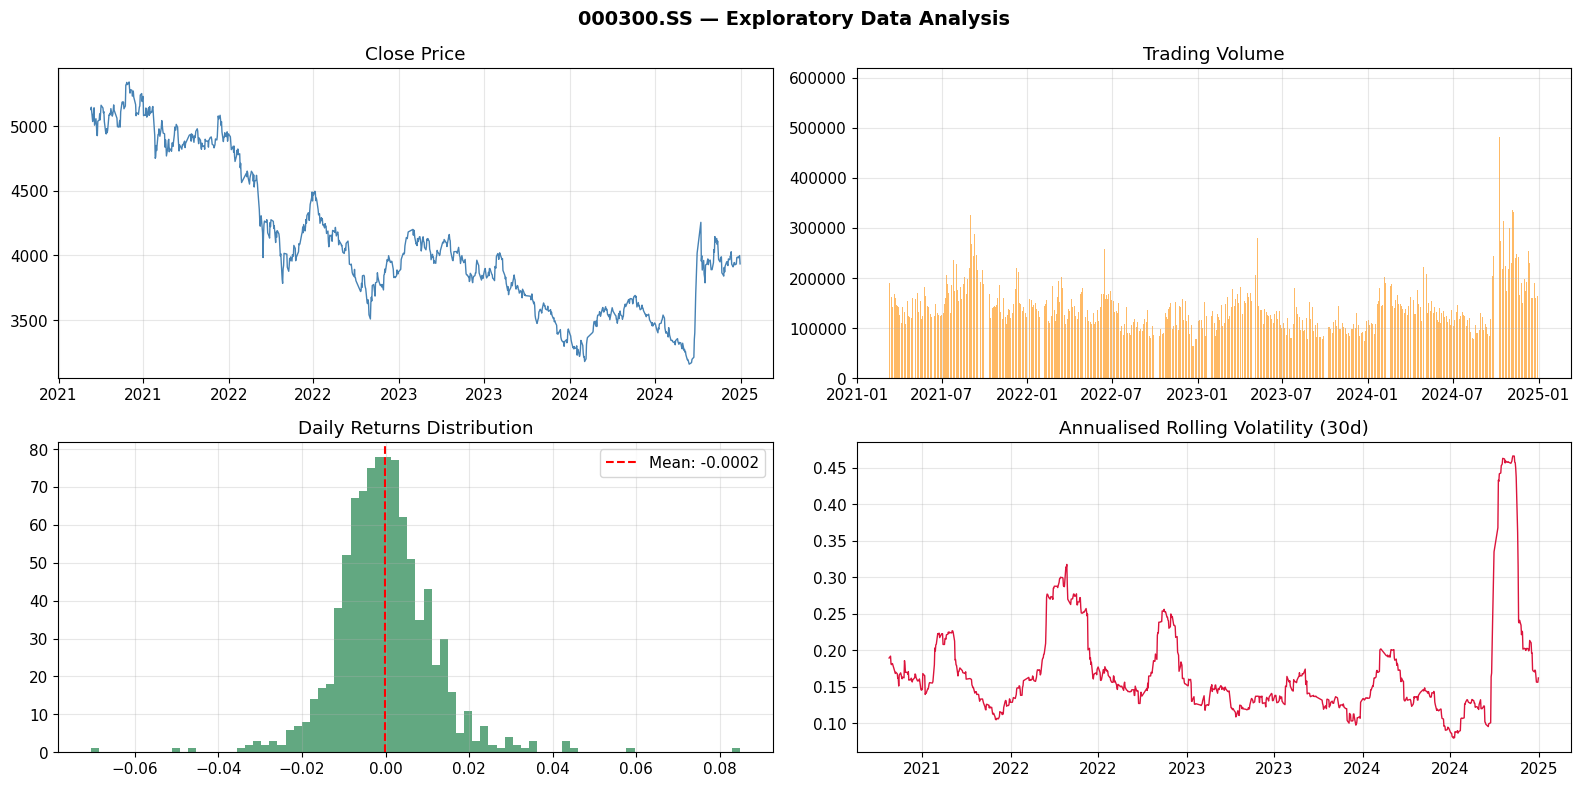


Basic statistics:
count     926.00
mean     4102.47
std       572.13
min      3159.25
25%      3656.94
50%      3980.96
75%      4577.49
max      5341.68
Name: Close, dtype: float64


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle(f'{TICKER} — Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Close price
axes[0, 0].plot(raw.index, raw['Close'], color='steelblue', linewidth=1)
axes[0, 0].set_title('Close Price')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Volume
axes[0, 1].bar(raw.index, raw['Volume'], color='darkorange', alpha=0.6, width=1)
axes[0, 1].set_title('Trading Volume')

# Daily returns
returns = raw['Close'].pct_change().dropna()
axes[1, 0].hist(returns, bins=80, color='seagreen', alpha=0.75, edgecolor='none')
axes[1, 0].axvline(returns.mean(), color='red', linestyle='--', label=f'Mean: {returns.mean():.4f}')
axes[1, 0].set_title('Daily Returns Distribution')
axes[1, 0].legend()

# Rolling volatility (30-day)
vol = returns.rolling(30).std() * np.sqrt(252)
axes[1, 1].plot(vol.index, vol, color='crimson', linewidth=1)
axes[1, 1].set_title('Annualised Rolling Volatility (30d)')
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print(f'\nBasic statistics:\n{raw["Close"].describe().round(2)}')

## 4. Feature engineering — technical indicators

In [6]:
def add_technical_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """Compute common technical indicators used in Chinese quant research."""
    d = df.copy()
    close = d['Close']
    high  = d['High']
    low   = d['Low']
    vol   = d['Volume']

    # ── Moving averages ──────────────────────────────────────────────────────
    for w in [5, 10, 20, 60]:
        d[f'MA{w}']  = close.rolling(w).mean()
        d[f'EMA{w}'] = close.ewm(span=w, adjust=False).mean()

    # ── MACD ─────────────────────────────────────────────────────────────────
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    d['MACD']        = ema12 - ema26
    d['MACD_signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_hist']   = d['MACD'] - d['MACD_signal']

    # ── RSI (14) ──────────────────────────────────────────────────────────────
    delta = close.diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rs    = gain / (loss + 1e-9)
    d['RSI'] = 100 - (100 / (1 + rs))

    # ── Bollinger Bands (20, 2σ) ──────────────────────────────────────────────
    mb = close.rolling(20).mean()
    std = close.rolling(20).std()
    d['BB_upper'] = mb + 2 * std
    d['BB_lower'] = mb - 2 * std
    d['BB_width'] = (d['BB_upper'] - d['BB_lower']) / mb   # normalised width
    d['BB_pos']   = (close - d['BB_lower']) / (d['BB_upper'] - d['BB_lower'] + 1e-9)

    # ── ATR (14) ──────────────────────────────────────────────────────────────
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs()
    ], axis=1).max(axis=1)
    d['ATR'] = tr.rolling(14).mean()

    # ── Volume indicators ─────────────────────────────────────────────────────
    d['Vol_MA20']  = vol.rolling(20).mean()
    d['Vol_ratio'] = vol / (d['Vol_MA20'] + 1e-9)

    # ── Price momentum ────────────────────────────────────────────────────────
    for lag in [1, 5, 10, 20]:
        d[f'Return_{lag}d'] = close.pct_change(lag)

    return d.dropna()


df = add_technical_indicators(raw)
print(f'Features: {list(df.columns)}')
print(f'Dataset shape after feature engineering: {df.shape}')

Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA5', 'EMA5', 'MA10', 'EMA10', 'MA20', 'EMA20', 'MA60', 'EMA60', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'BB_pos', 'ATR', 'Vol_MA20', 'Vol_ratio', 'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d']
Dataset shape after feature engineering: (867, 28)


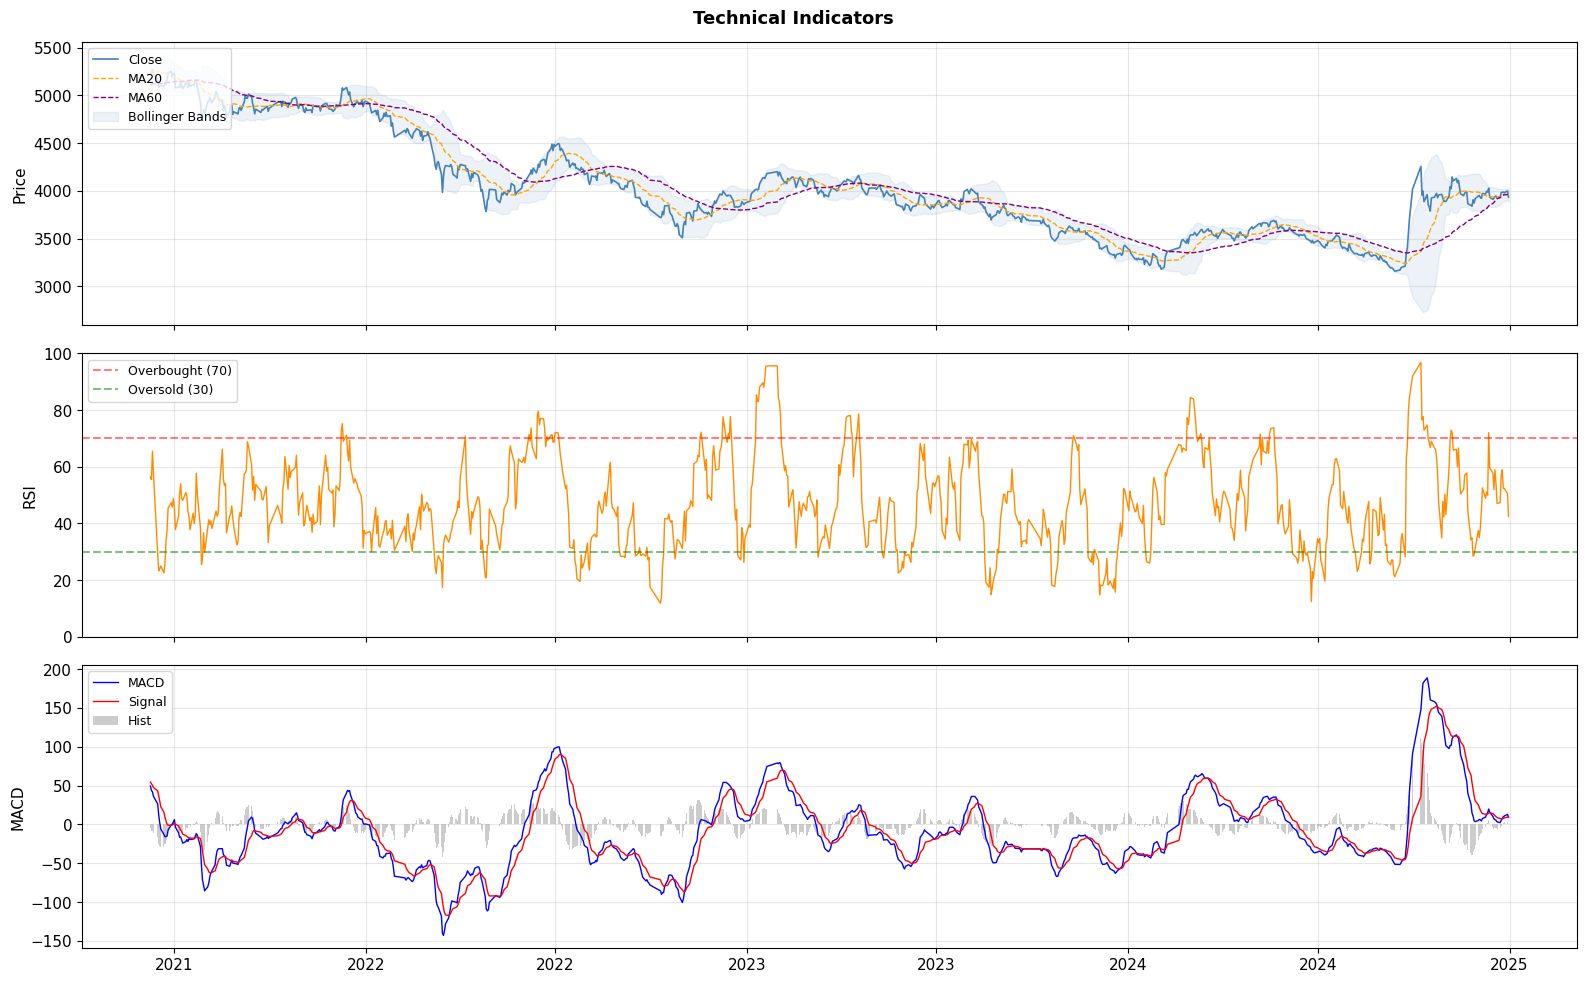

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
fig.suptitle('Technical Indicators', fontsize=13, fontweight='bold')

# Price + Bollinger Bands + MAs
axes[0].plot(df.index, df['Close'],    label='Close',    color='steelblue', linewidth=1.2)
axes[0].plot(df.index, df['MA20'],     label='MA20',     color='orange',    linewidth=1, linestyle='--')
axes[0].plot(df.index, df['MA60'],     label='MA60',     color='purple',    linewidth=1, linestyle='--')
axes[0].fill_between(df.index, df['BB_lower'], df['BB_upper'], alpha=0.1, color='steelblue', label='Bollinger Bands')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left', fontsize=9)

# RSI
axes[1].plot(df.index, df['RSI'], color='darkorange', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left', fontsize=9)

# MACD
axes[2].plot(df.index, df['MACD'],        label='MACD',   color='blue',  linewidth=1)
axes[2].plot(df.index, df['MACD_signal'], label='Signal', color='red',   linewidth=1)
axes[2].bar(df.index,  df['MACD_hist'],   label='Hist',   color='grey',  alpha=0.4, width=1)
axes[2].set_ylabel('MACD')
axes[2].legend(loc='upper left', fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

## 5. Data preprocessing — scaling & sequence creation

In [8]:
# Select feature columns (Close + all engineered features)
feature_cols = [c for c in df.columns if c not in ['Open', 'High', 'Low', 'Adj Close']]
target_idx   = feature_cols.index(TARGET_COL)
print(f'Using {len(feature_cols)} features. Target column index: {target_idx}')
print(f'Features: {feature_cols}')

# ── Train/test split (chronological — no shuffling!) ─────────────────────────
data    = df[feature_cols].values
n_test  = int(len(data) * TEST_RATIO)
n_train = len(data) - n_test
train_raw, test_raw = data[:n_train], data[n_train:]
print(f'\nTrain samples: {n_train}  |  Test samples: {n_test}')

# ── Normalise with MinMaxScaler fitted ONLY on train data ────────────────────
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)


def create_sequences(data, lookback, forecast=1, target_idx=0):
    """Slice rolling windows (X) and the next-day target (y)."""
    X, y = [], []
    for i in range(lookback, len(data) - forecast + 1):
        X.append(data[i - lookback: i])
        y.append(data[i + forecast - 1, target_idx])
    return np.array(X), np.array(y)


X_train, y_train = create_sequences(train_scaled, LOOKBACK, FORECAST, target_idx)
X_test,  y_test  = create_sequences(test_scaled,  LOOKBACK, FORECAST, target_idx)

print(f'\nX_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')

Using 25 features. Target column index: 0
Features: ['Close', 'Volume', 'MA5', 'EMA5', 'MA10', 'EMA10', 'MA20', 'EMA20', 'MA60', 'EMA60', 'MACD', 'MACD_signal', 'MACD_hist', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'BB_pos', 'ATR', 'Vol_MA20', 'Vol_ratio', 'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d']

Train samples: 694  |  Test samples: 173

X_train: (634, 60, 25)  y_train: (634,)
X_test:  (113, 60, 25)   y_test:  (113,)


## 6. Build the LSTM model

In [9]:
n_features = X_train.shape[2]

model = Sequential([
    # Layer 1 — Bidirectional LSTM (captures both past and future context)
    Bidirectional(
        LSTM(UNITS_L1, return_sequences=True, activation='tanh'),
        input_shape=(LOOKBACK, n_features)
    ),
    Dropout(DROPOUT),

    # Layer 2 — LSTM
    LSTM(UNITS_L2, return_sequences=False, activation='tanh'),
    Dropout(DROPOUT),

    # Output layer
    Dense(32, activation='relu'),
    Dense(1)
], name='Bidirectional_LSTM')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

model.summary()

Model: "Bidirectional_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)        │ (None, 60, 256)             │         157,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,985 (945.25 KB)

 Trainable params: 241,985 (945.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model

In [10]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-6, verbose=1
    )
]

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete. Best val_loss: {min(history.history["val_loss"]):.6f}')

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0522 - mae: 0.1669 - val_loss: 0.0084 - val_mae: 0.0880 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0088 - mae: 0.0709 - val_loss: 0.0012 - val_mae: 0.0269 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0056 - mae: 0.0586 - val_loss: 0.0023 - val_mae: 0.0415 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0045 - mae: 0.0519 - val_loss: 0.0014 - val_mae: 0.0325 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0035 - mae: 0.0455 - val_loss: 9.3106e-04 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0034 - mae: 0.0449 - val_loss: 0.0015 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0032 - mae: 0.0429 - val_loss: 0.0015 - val_mae: 0.0336 - learning_rate: 0.0010
Ep

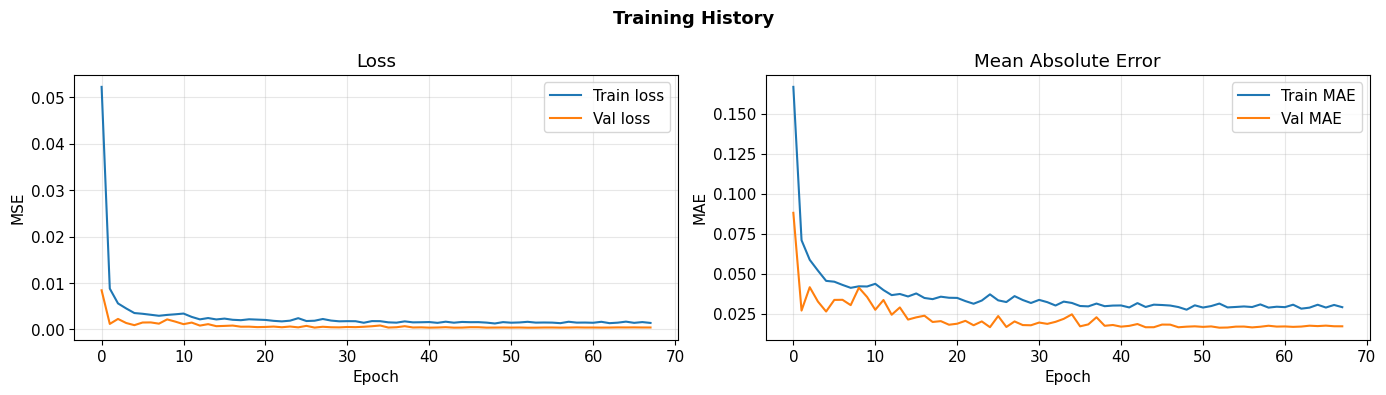

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training History', fontsize=13, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Evaluate & visualise predictions

In [12]:
# ── Predict & inverse-transform back to original price scale ─────────────────
def inverse_close(scaled_values, scaler, n_features, target_idx):
    """Reverse MinMaxScaler for the target column only."""
    dummy = np.zeros((len(scaled_values), n_features))
    dummy[:, target_idx] = scaled_values.ravel()
    return scaler.inverse_transform(dummy)[:, target_idx]


y_pred_scaled = model.predict(X_test, verbose=0)

y_pred = inverse_close(y_pred_scaled, scaler, n_features, target_idx)
y_true = inverse_close(y_test,        scaler, n_features, target_idx)

# ── Metrics ──────────────────────────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
dir_acc = np.mean(
    np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred))
) * 100

print('=' * 45)
print('           MODEL PERFORMANCE (TEST SET)')
print('=' * 45)
print(f'  RMSE             : {rmse:.4f}')
print(f'  MAE              : {mae:.4f}')
print(f'  MAPE             : {mape:.2f} %')
print(f'  Direction Acc.   : {dir_acc:.2f} %')
print('=' * 45)

           MODEL PERFORMANCE (TEST SET)
  RMSE             : 86.6467
  MAE              : 49.1497
  MAPE             : 1.29 %
  Direction Acc.   : 54.46 %


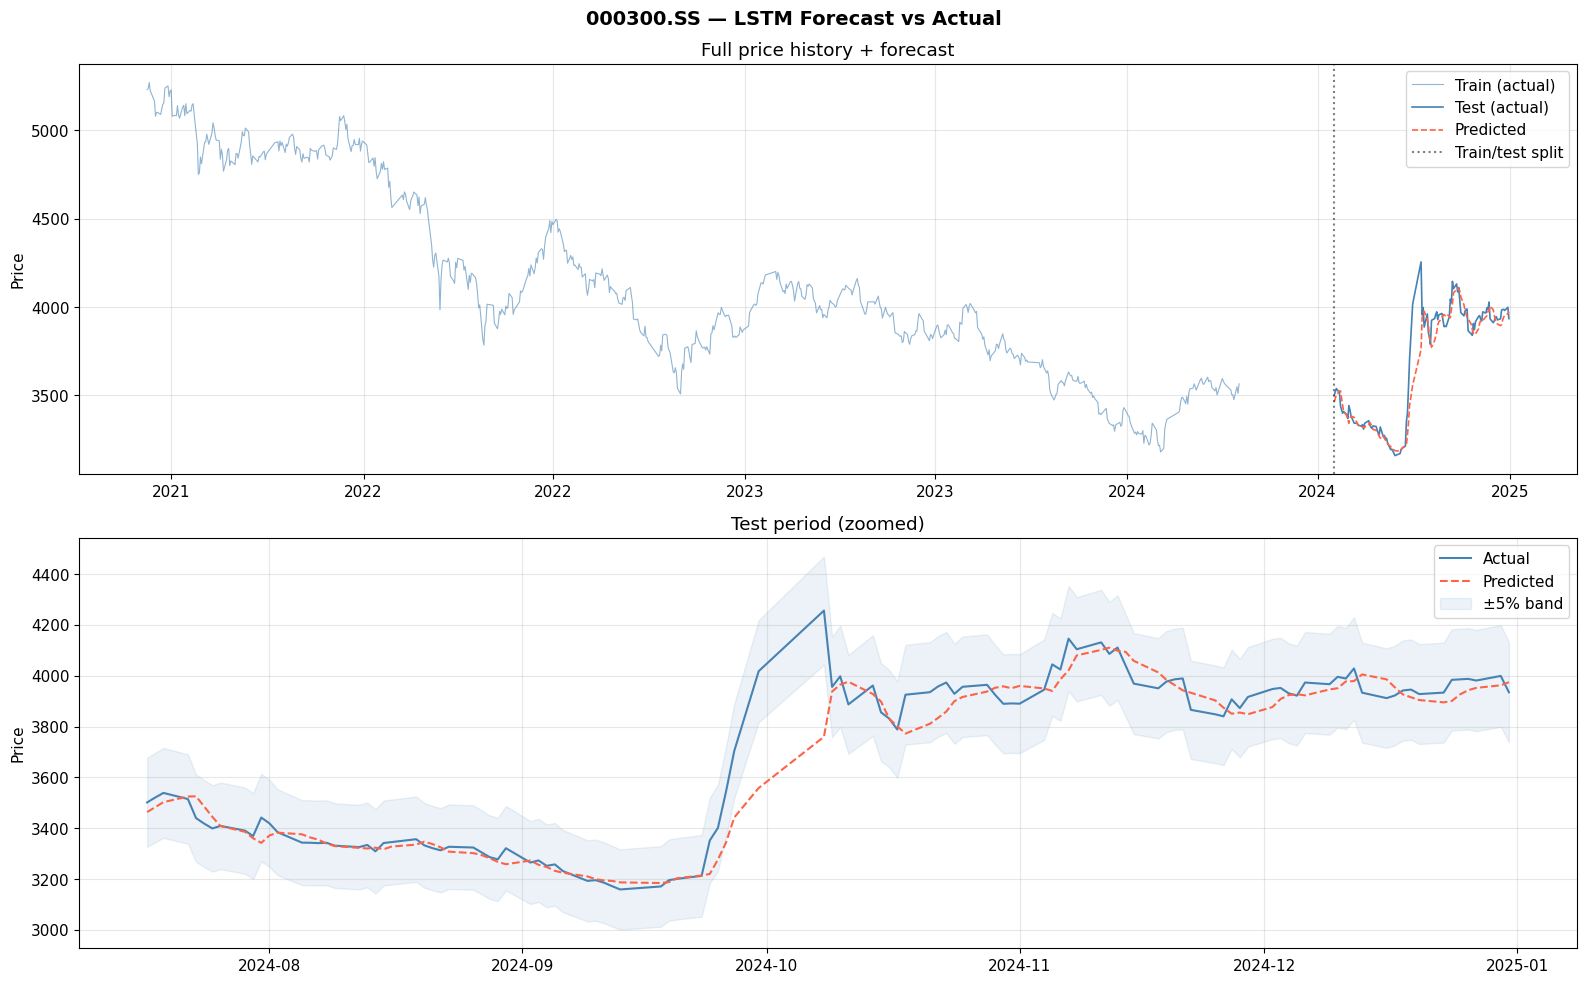

In [13]:
# Date index for test predictions
test_dates = df.index[n_train + LOOKBACK: n_train + LOOKBACK + len(y_true)]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'{TICKER} — LSTM Forecast vs Actual', fontsize=14, fontweight='bold')

# Full timeline (train + test)
train_dates = df.index[:n_train]
axes[0].plot(train_dates, df[TARGET_COL].values[:n_train],
             color='steelblue', linewidth=0.8, label='Train (actual)', alpha=0.6)
axes[0].plot(test_dates, y_true, color='steelblue', linewidth=1.2, label='Test (actual)')
axes[0].plot(test_dates, y_pred, color='tomato',    linewidth=1.2, label='Predicted', linestyle='--')
axes[0].axvline(test_dates[0], color='black', linestyle=':', alpha=0.5, label='Train/test split')
axes[0].set_title('Full price history + forecast')
axes[0].legend()
axes[0].set_ylabel('Price')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Zoom in on test period
axes[1].plot(test_dates, y_true, color='steelblue', linewidth=1.5, label='Actual')
axes[1].plot(test_dates, y_pred, color='tomato',    linewidth=1.5, label='Predicted', linestyle='--')
axes[1].fill_between(test_dates,
    y_true * 0.95, y_true * 1.05,
    alpha=0.1, color='steelblue', label='±5% band')
axes[1].set_title('Test period (zoomed)')
axes[1].legend()
axes[1].set_ylabel('Price')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

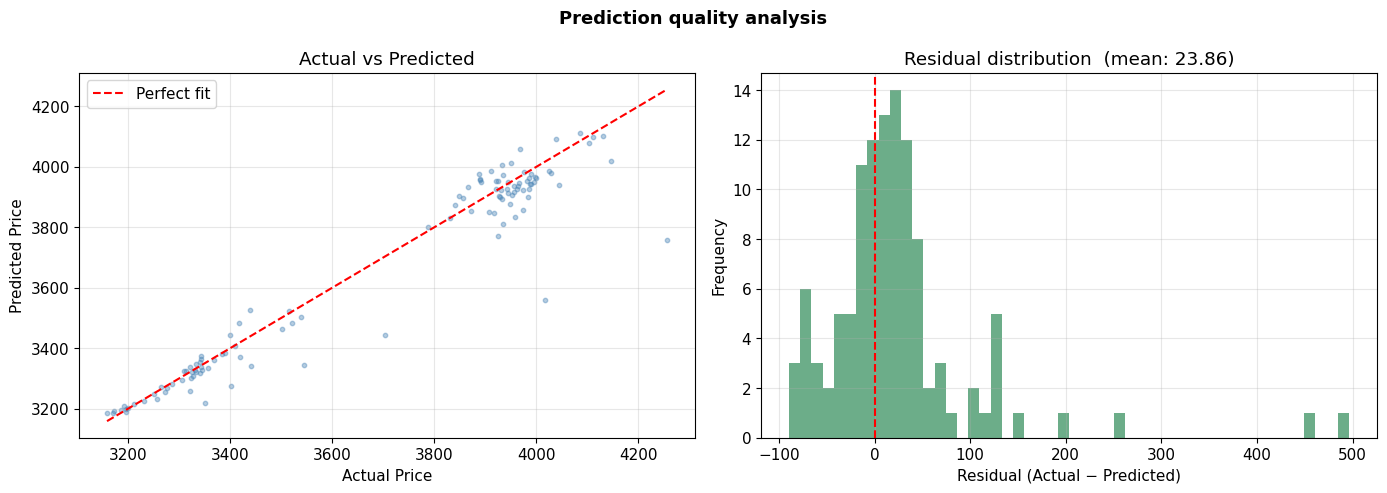

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction quality analysis', fontsize=13, fontweight='bold')

# Scatter: actual vs predicted
axes[0].scatter(y_true, y_pred, alpha=0.4, s=10, color='steelblue')
mn, mx = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('Actual vs Predicted')
axes[0].legend()

# Residual distribution
residuals = y_true - y_pred
axes[1].hist(residuals, bins=50, color='seagreen', alpha=0.7, edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'Residual distribution  (mean: {residuals.mean():.2f})')

plt.tight_layout()
plt.show()

## 9. Simple trading signal backtest

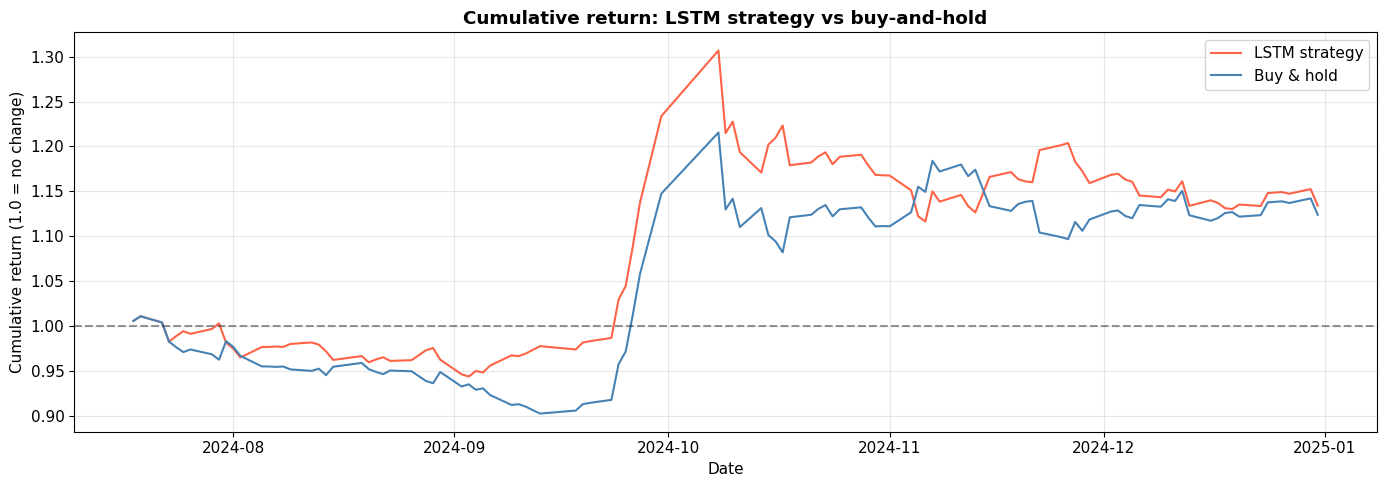

LSTM strategy total return : +13.40%
Buy-and-hold total return  : +12.38%
LSTM Sharpe ratio (annualised): 1.16
Direction accuracy         : 54.46%


In [15]:
# Strategy: buy when model predicts price increase, sell/short when it predicts a fall
pred_returns = np.diff(y_pred)
true_returns = np.diff(y_true)

# Signal: +1 = long, -1 = short
signal = np.sign(pred_returns)

# Strategy returns (signal × actual next-day return)
strategy_returns = signal * (true_returns / y_true[:-1])  # pct return
bh_returns       = true_returns / y_true[:-1]             # buy-and-hold

# Cumulative returns
cum_strategy = np.cumprod(1 + strategy_returns)
cum_bh       = np.cumprod(1 + bh_returns)

plt.figure(figsize=(14, 5))
plt.plot(test_dates[1:], cum_strategy, color='tomato',    linewidth=1.5, label='LSTM strategy')
plt.plot(test_dates[1:], cum_bh,       color='steelblue', linewidth=1.5, label='Buy & hold')
plt.axhline(1, color='black', linestyle='--', alpha=0.4)
plt.title('Cumulative return: LSTM strategy vs buy-and-hold', fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Cumulative return (1.0 = no change)')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

total_return_lstm = (cum_strategy[-1] - 1) * 100
total_return_bh   = (cum_bh[-1]       - 1) * 100
sharpe_lstm = strategy_returns.mean() / (strategy_returns.std() + 1e-9) * np.sqrt(252)

print(f'LSTM strategy total return : {total_return_lstm:+.2f}%')
print(f'Buy-and-hold total return  : {total_return_bh:+.2f}%')
print(f'LSTM Sharpe ratio (annualised): {sharpe_lstm:.2f}')
print(f'Direction accuracy         : {dir_acc:.2f}%')

## 10. Save the model

In [16]:
model.save('lstm_china_stock_model.h5')
print('Model saved → lstm_china_stock_model.h5')

# Reload example
# from tensorflow.keras.models import load_model
# loaded_model = load_model('lstm_china_stock_model.h5')

Model saved → lstm_china_stock_model.h5


## 11. Summary & next steps

### What this notebook built
| Component | Detail |
|-----------|--------|
| Data | Yahoo Finance — CSI 300 / any A-share |
| Features | OHLCV + MA, EMA, MACD, RSI, Bollinger Bands, ATR, Volume ratios, momentum returns |
| Model | Bidirectional LSTM → LSTM → Dense |
| Training | Adam optimiser, EarlyStopping, ReduceLROnPlateau |
| Evaluation | RMSE, MAE, MAPE, Direction Accuracy |
| Backtest | Simple long/short signal vs buy-and-hold |

### Improvements methods
- **Attention mechanism** — add a self-attention layer after the LSTM for better long-range dependencies
- **Transformer model** — replace LSTM with a Temporal Fusion Transformer (TFT) for state-of-the-art performance
- **Sentiment features** — integrate news sentiment from Chinese sources (Sina Finance, Eastmoney) via NLP
- **Multi-stock** — use a Graph Neural Network (GNN) to model cross-stock correlations across the A-share universe
- **Ensemble** — combine LSTM predictions with XGBoost on fundamental factors
- **Walk-forward validation** — replace a single train/test split with rolling re-training windows


